# DTLZ4 Results

In [1]:
import multiprocessing
from functools import partial
from meamt_core import build_toolbox, gen_inicial_tables, run, generate_dtlz3_front_random
from deap import benchmarks

# 1. Parâmetros
K = 10
NPOP = 800
NGEN = 300
NOBJ = 4 
IND_SIZE = NOBJ + K - 1 
NUM_TABLES = int((1 << NOBJ)) 
MAX_TABLE_SIZE = int(NPOP / NUM_TABLES)
REF_POINT_HV = [1.1]*NOBJ

# 2. Configurando o Toolbox de forma segura para o multiprocessing
# O 'partial' "congela" o argumento obj=NOBJ na função nativa do DEAP
func_dtlz4_segura = partial(benchmarks.dtlz4, obj=NOBJ, alpha=100)
toolbox = build_toolbox(func_dtlz4_segura, IND_SIZE, NPOP, NOBJ)

# =======================================================
# A TRAVA DE SEGURANÇA (OBRIGATÓRIA NO JUPYTER/WINDOWS)
# =======================================================
if __name__ == '__main__':
    # Cria o pool apenas se for o processo principal
    num_cores = multiprocessing.cpu_count() - 1 
    pool = multiprocessing.Pool(processes=num_cores)
    toolbox.register("map", pool.map) 

    # 3. Inicialização
    pop_inicial = toolbox.population()
    
    # Avaliação inicial
    fitnesses = toolbox.map(toolbox.evaluate, pop_inicial)
    for ind, fit in zip(pop_inicial, fitnesses):
        ind.fitness.values = fit

    tabelas = gen_inicial_tables(pop_inicial, NUM_TABLES, MAX_TABLE_SIZE, NOBJ)
    pareto_real = generate_dtlz3_front_random(NOBJ, 1000)
    reset = 1
    print(f"Iniciando evolução usando {num_cores} threads...")

    # 4. Executando o MEAMT
    logbook = run(tabelas, pareto_real, NUM_TABLES, MAX_TABLE_SIZE, NGEN, toolbox, 0.9, 1.0, REF_POINT_HV, NOBJ, reset)

    # Fechando os processos corretamente
    pool.close()
    pool.join()

    print("Evolução concluída!")

Iniciando evolução usando 15 threads...
Evolução concluída!


[1.0, 1.0, 2.4664518796457813e-05, 0.4998034899228737, 0.5000891208029585, 0.5001400488571838, 0.5000482434337318, 0.5001863308401517, 0.5001429689458751, 0.5000879707921805, 0.50015234885014, 0.4998412590215849, 0.500082608278789]
[0.0005517456269395551, 0.9999999889016319, 0.00018418046533708043, 0.7286094876499842, 0.16429264948637962, 0.5040650170042674, 0.8589741032455517, 0.4878239819397385, 0.4879948189478134, 0.7107639856107458, 0.6333845940218543, 0.9854471703044634, 0.03190729450105567]
[2.8400075942514036e-05, 6.226784350362065e-05, 0.0003065026942688535, 0.4999283436065201, 0.5000156826968917, 0.5001358507123351, 0.49995428050250296, 0.5004688706487125, 0.5000554470422123, 0.505422280646003, 0.5003174066986232, 0.49990698822113094, 0.5000056002512311]
[0.0003659658670645497, 0.0002184730840533119, 1.0, 0.49946565612021604, 0.5000900165586705, 0.5001333173715601, 0.49985581287119785, 0.5001727234514144, 0.4999569415843666, 0.5000732233599456, 0.4991723967343636, 0.4998411112

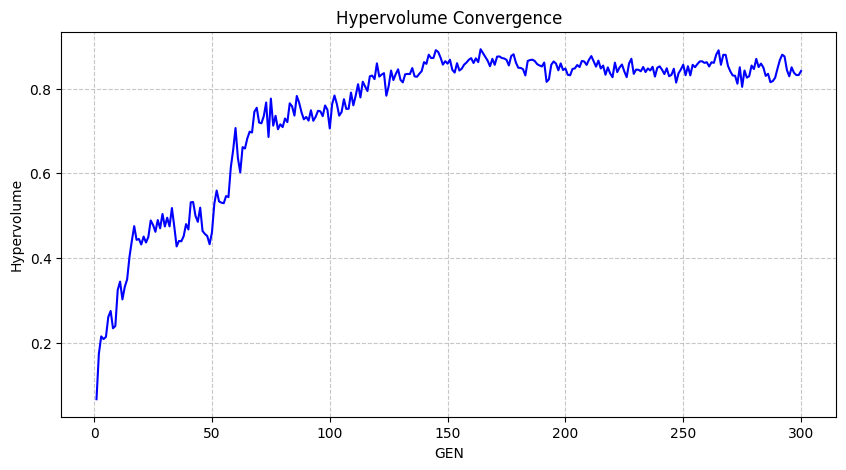

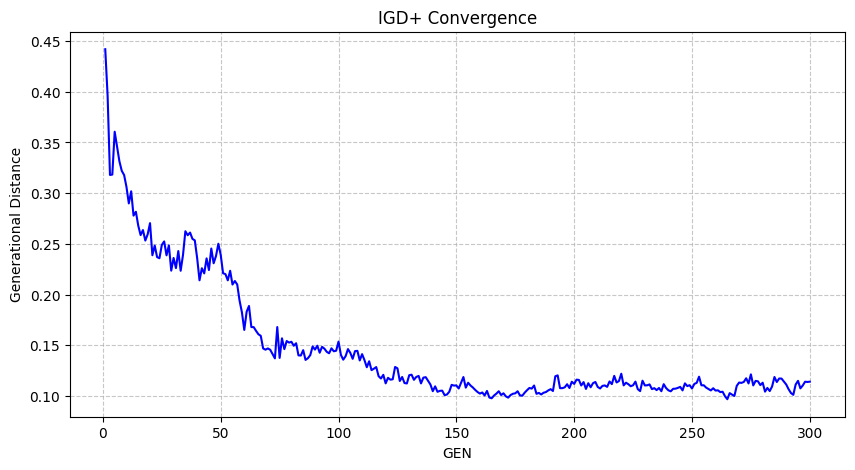

In [2]:
import matplotlib.pyplot as plt
# 3D Graphic of final pareto front
for ind in tabelas[0]:
    print(ind)
# Hypervolume Graphic
gen = logbook.select("gen")
fit_hv = logbook.select("hypervolume")
plt.figure(figsize=(10, 5))
plt.plot(gen, fit_hv, 'b-')
plt.title("Hypervolume Convergence")
plt.xlabel('GEN')
plt.ylabel('Hypervolume')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# IGD+ Graphic
gen = logbook.select("gen")
fit_igd = logbook.select("igd_plus")
plt.figure(figsize=(10, 5))
plt.plot(gen, fit_igd, 'b-')
plt.title("IGD+ Convergence")
plt.xlabel('GEN')
plt.ylabel('Generational Distance')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()